# Paper-1 reproduction: five recordings, four voice segments

This notebook walks through the **full** paper-1 pipeline — pitch
tracking, reliability filtering, three-axis metrics, per-recording
aggregation, type classification, and all six paper figures — across
the entire five-recording corpus.

It is the batch counterpart of [`01_quickstart.ipynb`](01_quickstart.ipynb),
which analyses a single segment.

## Audio assumptions

The paper-1 corpus uses five commercial recordings that **cannot be
redistributed** (conductor / reciter):

- `ath-1973`  Atherton / Thomas
- `hul-2012`  Hůla / Caiello
- `bou-1961`  Boulez / Pilarczyk
- `bou-1977`  Boulez / Minton
- `her-1991`  Herreweghe / Pousseur

To reproduce the paper numbers, place these recordings under
`data/audio/<recording_id>/<piece_id>.wav` (or any extension supported
by `librosa`) **and separate the vocals with Demucs first** — the
paper pipeline runs pYIN on the separated vocals stem, not the raw mix:

```
python -m demucs.separate --two-stems vocals -n htdemucs \
    -o data/audio/separated <audio file>
```

(see the separation cell in `01_quickstart.ipynb`; requires the
`separation` extra). The loader below automatically prefers
`data/audio/separated/htdemucs/<name>/vocals.wav` when present and
falls back to the raw file — on the raw mix more notes are flagged
unreliable (the paper reports 24 flags unseparated vs 15 separated).

Recordings whose audio is missing are skipped with a warning, so the
notebook works on any available subset. To batch-run the demo
recording fetched by `scripts/fetch_audio.py` instead, add
`"sch-1940-sti"` to `RECORDINGS` in the configuration cell.

**Reproduction accuracy.** pYIN is run per segment here, so frame
alignment differs marginally from the analysis pipeline that produced
the released [`results/segment_metrics.csv`](../results/segment_metrics.csv).
In our runs all 20 kept-note counts and 19 of 20 per-segment metric
triples match the released values within noise (offsets within 5
cents), and the classification of all five recordings is identical;
the one visible deviation is the contour of ath-1973 m8, a dense
chromatic segment sensitive to frame placement. The authoritative
paper numbers are the CSVs in [`results/`](../results/README.md).

See [LEGAL_NOTICE.md](../LEGAL_NOTICE.md) for the legal status of the
fetched demo audio.


## 1. Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make the package importable when running from the repo without `pip install`.
pkg_path = Path("..").resolve() / "src"
if str(pkg_path) not in sys.path:
    sys.path.insert(0, str(pkg_path))

import sprechstimme_pitch as sp
from sprechstimme_pitch import config, metrics, pipeline, plotting

print(f"sprechstimme_pitch version: {sp.__version__}")

REPO_ROOT = Path("..").resolve()
AUDIO_DIR = REPO_ROOT / "data" / "audio"
METADATA_DIR = REPO_ROOT / "data" / "metadata"
EXPORT_DIR = REPO_ROOT / "outputs" / "paper1"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


sprechstimme_pitch version: 0.1.0


## 2. Configuration

Define which recordings to analyse and where to find their audio. The
default list is the paper-1 corpus; trim it if you only have a subset.


In [2]:
# Paper-1 corpus identifiers. Add "sch-1940-sti" to also run the batch on
# the demo recording fetched by scripts/fetch_audio.py.
RECORDINGS = ["ath-1973", "hul-2012", "bou-1961", "bou-1977", "her-1991"]
PIECE_ID = "07"

# The pYIN parameters are single-sourced from the package; the pipeline
# functions use them as defaults.
print(
    f"pYIN config: sr={config.SR_PYIN}, fmin={config.FMIN_HZ} (C3), "
    f"fmax={config.FMAX_HZ} (C6), frame={config.FRAME_LENGTH}, "
    f"hop={config.HOP_LENGTH}"
)

# Filenames written by scripts/fetch_audio.py for recordings whose audio
# filename does not start with the recording id.
DEMO_AUDIO = {
    "sch-1940-sti": "07.DerKrankeMondtheSickMoon.mp3",
}


def find_audio(recording_id: str) -> Path | None:
    """Return the best audio source for this recording.

    Prefers a Demucs-separated vocals stem (the paper-1 pipeline input)
    over the raw mix. Search order:

      1. ``data/audio/separated/htdemucs/<name>/vocals.wav`` where
         ``<name>`` starts with ``recording_id``
      2. the known demo filename from ``DEMO_AUDIO``
      3. ``data/audio/<recording_id>/`` (any audio extension)
      4. ``data/audio/`` for a file whose stem starts with ``recording_id``

    When a raw file is found via 2--4, its separated stem
    ``separated/htdemucs/<file stem>/vocals.wav`` is used if it exists.
    """
    exts = (".wav", ".flac", ".mp3", ".m4a", ".ogg", ".aiff", ".aif")
    sep_root = AUDIO_DIR / "separated" / "htdemucs"

    if sep_root.is_dir():
        for d in sorted(sep_root.iterdir()):
            if d.is_dir() and d.name.startswith(recording_id):
                v = d / "vocals.wav"
                if v.exists():
                    return v

    def _sep_or_raw(p: Path) -> Path:
        v = sep_root / p.stem / "vocals.wav"
        return v if v.exists() else p

    demo_name = DEMO_AUDIO.get(recording_id)
    if demo_name and (AUDIO_DIR / demo_name).exists():
        return _sep_or_raw(AUDIO_DIR / demo_name)

    sub = AUDIO_DIR / recording_id
    if sub.is_dir():
        for ext in exts:
            for p in sorted(sub.glob(f"*{ext}")):
                return _sep_or_raw(p)

    for ext in exts:
        for p in sorted(AUDIO_DIR.glob(f"{recording_id}*{ext}")):
            return _sep_or_raw(p)

    return None


pYIN config: sr=22050, fmin=130.8 (C3), fmax=1046.5 (C6), frame=2048, hop=256


## 3. Load metadata

In [3]:
segments_df = pd.read_csv(METADATA_DIR / "segments.csv")
score_events_df = pd.read_csv(METADATA_DIR / "score_events.csv")
segment_score_map_df = pd.read_csv(METADATA_DIR / "segment_score_map.csv")

# Restrict to the piece under analysis (piece_id is stored as an integer).
piece_no = int(PIECE_ID)
segments_df = segments_df[segments_df["piece_id"].astype(int) == piece_no].copy()
score_events_df = score_events_df[score_events_df["piece_id"].astype(int) == piece_no].copy()
segment_score_map_df = segment_score_map_df.merge(
    segments_df[["recording_id", "segment_id"]],
    on=["recording_id", "segment_id"],
    how="inner",
)

# Regression guards: the bundled metadata must survive the piece filter.
assert not segments_df.empty, "piece filter returned no segments"
assert not score_events_df.empty, "piece filter returned no score events"
assert not segment_score_map_df.empty, "segment-score map join is empty"

print(f"Recordings in metadata     : {sorted(segments_df['recording_id'].unique())}")
print(f"Voice segments in metadata : {sorted(segments_df['segment_id'].unique())}")
print(f"Score events for piece {PIECE_ID}: {len(score_events_df)} notes")


Recordings in metadata     : ['ath-1973', 'bou-1961', 'bou-1977', 'her-1991', 'hul-2012', 'sch-1940-sti']
Voice segments in metadata : ['seg_p07_m10_m11', 'seg_p07_m13', 'seg_p07_m18b6_m19b5', 'seg_p07_m5', 'seg_p07_m8']
Score events for piece 07: 72 notes


## 4. Per-segment analysis

For each ``(recording, segment)`` pair we:

1. Load the audio slice for that segment.
2. Run pYIN on the slice.
3. For every score event mapped to that segment, derive
   ``voiced_ratio``, ``f0_iqr_cent``, the median observed pitch, and
   the resulting ``is_pyin_unreliable`` flag.
4. Pass the per-note arrays to
   :func:`sprechstimme_pitch.metrics.compute_three_axis_metrics`.

Recordings with no audio on disk are skipped with a warning.


In [4]:
# The per-segment analysis lives in the package (sprechstimme_pitch.pipeline)
# so it is covered by the test suite; this cell only drives it and displays
# the per-segment values.
all_notes = []
segment_metrics = {}  # rec_id -> list[ThreeAxisMetrics]
missing_audio = []

for rec_id in RECORDINGS:
    audio_path = find_audio(rec_id)
    if audio_path is None:
        print(f"[skip] {rec_id}: no audio file found in {AUDIO_DIR}")
        missing_audio.append(rec_id)
        continue

    print(f"[run]  {rec_id}: using {audio_path.relative_to(AUDIO_DIR)}")
    rec_segments = segments_df[segments_df["recording_id"] == rec_id]
    if rec_segments.empty:
        print(f"  [skip] {rec_id}: no segments in metadata")
        continue

    metrics_list = []
    for _, seg_row in rec_segments.iterrows():
        result = pipeline.analyse_segment(
            audio_path, seg_row, segment_score_map_df, score_events_df,
        )
        if result is None:
            continue
        m, notes_df = result
        metrics_list.append(m)
        all_notes.append(notes_df)
        print(
            f"  {seg_row['segment_id']:25s} "
            f"offset={m.register_offset_cent:+7.1f}c  "
            f"range={m.range_compression:5.2f}  "
            f"contour={m.contour_correlation:+5.2f}  "
            f"n={m.n_notes_used}"
        )
    if metrics_list:
        segment_metrics[rec_id] = metrics_list

if missing_audio:
    print()
    print(f"Missing audio for: {missing_audio}")
    print("Place the corresponding files under data/audio/ to include them.")


[run]  ath-1973: using separated/htdemucs/ath-1973/vocals.wav


  seg_p07_m18b6_m19b5       offset=  -30.2c  range= 0.93  contour=+0.97  n=7


  seg_p07_m5                offset=  -52.7c  range= 0.79  contour=+0.90  n=6


  seg_p07_m8                offset=  -10.2c  range= 1.10  contour=+0.70  n=7


  seg_p07_m13               offset=  -15.2c  range= 1.42  contour=+0.87  n=4


...

  seg_p07_m13               offset=  -60.2c  range= 1.13  contour=+0.87  n=4


[run]  her-1991: using separated/htdemucs/her-1991/vocals.wav


  seg_p07_m18b6_m19b5       offset=  -65.2c  range= 1.37  contour=-0.50  n=4


  seg_p07_m5                offset= -360.2c  range= 0.81  contour=+1.00  n=5


  seg_p07_m8                offset= -290.2c  range= 0.55  contour=+0.95  n=5
  seg_p07_m13               offset= -350.2c  range= 0.81  contour=+0.00  n=4


## 5. Per-recording aggregation

`metrics.aggregate_metrics` reduces the per-segment list to four numbers
per recording: median register offset, median range compression, median
contour correlation, and the std of contour across segments (the
*dynamic* axis).


In [5]:
agg_rows = []
for rec_id, metrics_list in segment_metrics.items():
    agg = metrics.aggregate_metrics(metrics_list)
    agg["recording_id"] = rec_id
    agg["n_segments"] = len(metrics_list)
    agg_rows.append(agg)

SUMMARY_COLS = [
    "recording_id",
    "n_segments",
    "register_offset_cent",
    "range_compression",
    "contour_correlation_median",
    "contour_correlation_std",
]
recording_summary = pd.DataFrame(agg_rows, columns=SUMMARY_COLS)

if recording_summary.empty:
    print("No recordings analysed — place audio under data/audio/ (see the intro cell).")
else:
    print(recording_summary.to_string(index=False))
    recording_summary.to_csv(EXPORT_DIR / "recording_summary.csv", index=False)
    print(f"\nSaved: {EXPORT_DIR / 'recording_summary.csv'}")


recording_id  n_segments  register_offset_cent  range_compression  contour_correlation_median  contour_correlation_std
    ath-1973           4            -22.669179           1.016258                    0.883013                 0.100144
    hul-2012           4            -30.169179           1.110550                    0.883013                 0.054096
    bou-1961           4           -665.169179           0.836325                    0.866025                 0.067134
    bou-1977           4            -25.169179           1.038479                    0.956066                 0.049881
    her-1991           4           -320.169179           0.806665                    0.474342                 0.637442

Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/paper1/recording_summary.csv


## 6. Performance type classification

Decision flow (see `metrics.classify_performance` and
[`docs/method.md`](../docs/method.md) §3):

```
contour_std > 0.3          -> dynamic
|offset|    > 400 cents    -> directed-recitation
otherwise                   -> score-faithful
```


In [6]:
if recording_summary.empty:
    print("Nothing to classify.")
else:
    recording_summary["performance_type"] = recording_summary.apply(
        lambda r: metrics.classify_performance(
            register_offset_cent=r["register_offset_cent"],
            contour_std=r["contour_correlation_std"],
        ),
        axis=1,
    )
    print(recording_summary[["recording_id", "performance_type"]].to_string(index=False))


recording_id    performance_type
    ath-1973      score-faithful
    hul-2012      score-faithful
    bou-1961 directed-recitation
    bou-1977      score-faithful
    her-1991             dynamic


## 7. Figure 1 — Radar chart

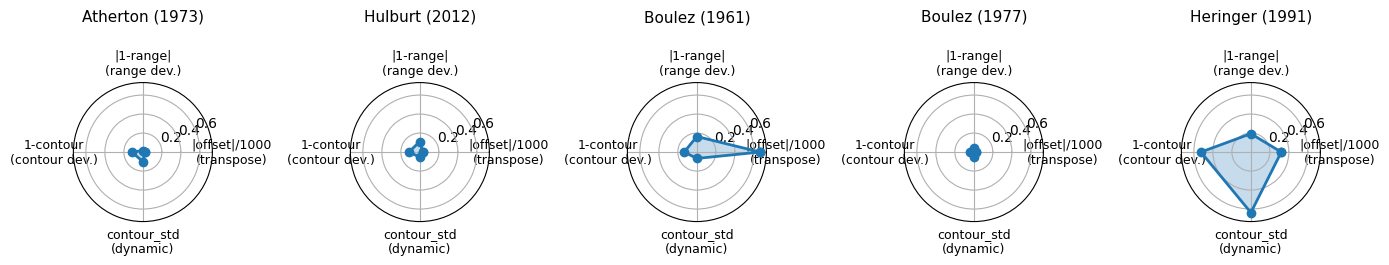

Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/paper1/fig1_radar.png


In [7]:
recordings_data = {}
for _, r in recording_summary.iterrows():
    recordings_data[r["recording_id"]] = plotting.four_axes_normalize(
        register_offset_cent=r["register_offset_cent"],
        range_compression=r["range_compression"],
        contour_correlation=r["contour_correlation_median"],
        contour_std=r["contour_correlation_std"],
    )

if recordings_data:
    fig, _ = plotting.plot_radar_chart(recordings_data)
    fig.savefig(EXPORT_DIR / "fig1_radar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {EXPORT_DIR / 'fig1_radar.png'}")
else:
    print("No recordings to plot.")


## 8. Figure 2 — PCA biplot (axis independence)

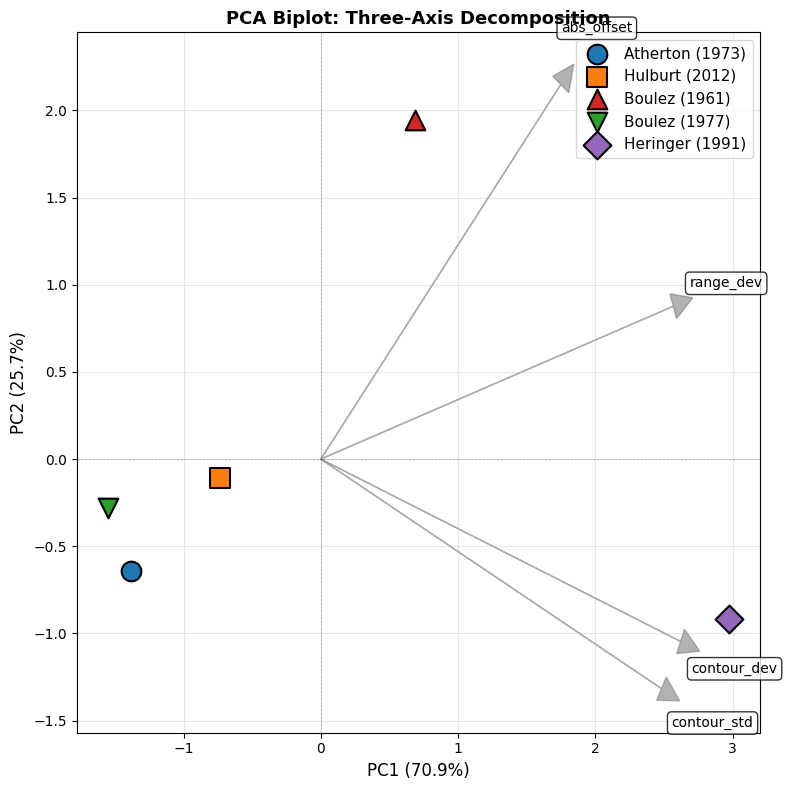

Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/paper1/fig2_pca_biplot.png


In [8]:
if len(recordings_data) >= 3:
    fig, _ = plotting.plot_pca_biplot(recordings_data)
    fig.savefig(EXPORT_DIR / "fig2_pca_biplot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {EXPORT_DIR / 'fig2_pca_biplot.png'}")
else:
    print(f"PCA biplot needs >=3 recordings; have {len(recordings_data)}.")


## 9. Figure 3 — Type classification flow

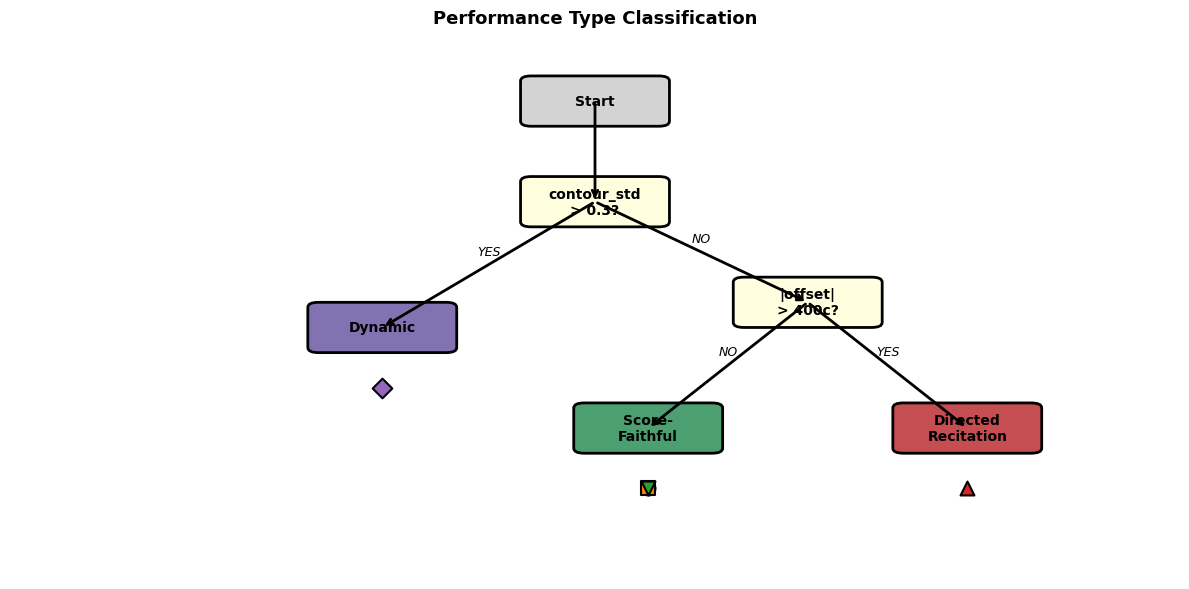

Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/paper1/fig3_type_flow.png


In [9]:
flow_data = {
    r["recording_id"]: (r["register_offset_cent"], r["contour_correlation_std"])
    for _, r in recording_summary.iterrows()
}

if flow_data:
    fig, _ = plotting.plot_type_classification_flow(flow_data)
    fig.savefig(EXPORT_DIR / "fig3_type_flow.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {EXPORT_DIR / 'fig3_type_flow.png'}")


## 10. Per-note diagnostics export

For audit and downstream analysis we export every per-note diagnostic
(observed cents, score reference, error, voicing, IQR, the issue-#12
flag and its reasons) collected during the loop.


In [10]:
if all_notes:
    notes_all_df = pd.concat(all_notes, ignore_index=True)
    notes_all_df.to_csv(EXPORT_DIR / "note_errors_all_segments.csv", index=False)
    print(f"Saved: {EXPORT_DIR / 'note_errors_all_segments.csv'}")
    n_unreliable = int(notes_all_df["is_pyin_unreliable"].sum())
    print(f"Total notes: {len(notes_all_df)}  unreliable: {n_unreliable}")
else:
    print("No per-note data collected.")


Saved: /Users/gsuzuki/projects/research/sprechstimme-pitch/outputs/paper1/note_errors_all_segments.csv
Total notes: 120  unreliable: 15


## Summary

This notebook is the reference implementation of the paper-1 batch
pipeline:

1. iterate over `(recording, segment)` pairs;
2. apply pitch tracking, reliability filtering, and three-axis metrics
   per segment;
3. aggregate to per-recording numbers;
4. classify each recording into one of three performance types;
5. produce the three core figures (radar, PCA biplot, decision flow);
6. export the per-recording summary and per-note diagnostics CSVs.

For the full set of paper-1 figures (Boulez 1961-1977 arrow,
her-1991 segment-level dynamics, summary table) extend the per-segment
loop above to retain segment-level metrics and add the matching
plotting helpers.

Numerical reproduction of the paper requires the five commercial
recordings listed at the top of this notebook; without them the
notebook will run on whatever subset is available, including the
single Stiedry-Wagner 1940 file fetched by `scripts/fetch_audio.py`.
